In [11]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from panel_segmentation import utils
import glob
import matplotlib.pyplot as plt
from PIL import Image
import os
from shapely.geometry import Polygon
import geopandas
from mmengine import Config
from mmdet.apis import init_detector, inference_detector
from mmdet.registry import VISUALIZERS
from shapely.geometry import Polygon
import mmcv
import numpy as np
import pandas as pd
import torch

# Panel Detection

Download the model from the Hugging Face repository, if it's not already present in the /models folder (https://huggingface.co/kperrynrel/panel-segmentation-models/tree/main).

In [12]:
utils.downloadModel(
    filename="panel_detection_model.pth"
)

Model already exists at C:\Users\kperry\OneDrive - NLR\Documents\source\repos\Panel-Segmentation\panel_segmentation\models\panel_detection_model.pth, skipping download.


'C:\\Users\\kperry\\OneDrive - NLR\\Documents\\source\\repos\\Panel-Segmentation\\panel_segmentation\\models\\panel_detection_model.pth'

The following example uses the panel detection pipeline to detect solar panels in satellite imagery and get their mounting configuration and azimuth. Let's use an NREL site as an example and get its latitude-longitude coordinates.

In [13]:
#Example latitude-longitude coordinates to run the analysis on.
latitude = 39.7407
longitude = -105.1694    
google_maps_api_key = "YOUR API KEY HERE"
file_name = "../../../panel_segmentation/examples/Panel_Detection_Examples/sat_img.png"

Load in the image and declare it as a numpy array.

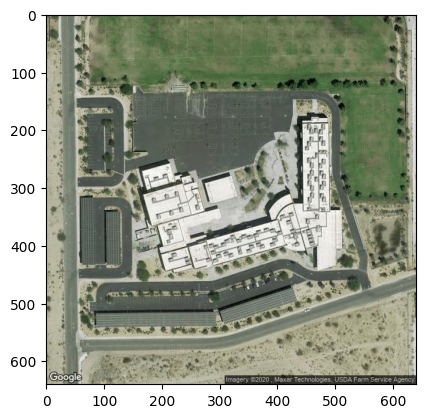

In [14]:
x = Image.open(file_name)
plt.imshow(x)
plt.show()

Read in the Panel-detection model for testing.

In [15]:
# Get hail model and checkpoint
cfg = Config.fromfile("../../../panel_segmentation/models/panel_detection_config.py")
checkpoint_file = "../../../panel_segmentation/models/panel_detection_model.pth"
model = init_detector(cfg, device='cpu')
checkpoint = torch.load(checkpoint_file, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['state_dict'])
visualizer = VISUALIZERS.build(model.cfg.visualizer)

C:\Users\kperry\.conda\envs\deep-learning\Lib\site-packages\mmdet\apis\inference.py:70: UserWarning: checkpoint is None, use COCO classes by default.
  warnings.warn('checkpoint is None, use COCO classes by default.')
C:\Users\kperry\.conda\envs\deep-learning\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


Run the image through model. 

C:\Users\kperry\.conda\envs\deep-learning\Lib\site-packages\mmdet\models\layers\se_layer.py:158: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
C:\Users\kperry\.conda\envs\deep-learning\Lib\site-packages\mmdet\models\backbones\csp_darknet.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
C:\Users\kperry\.conda\envs\deep-learning\Lib\site-packages\numpy\_core\fromnumeric.py:45: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return conv.wrap(result, to_scalar=False)


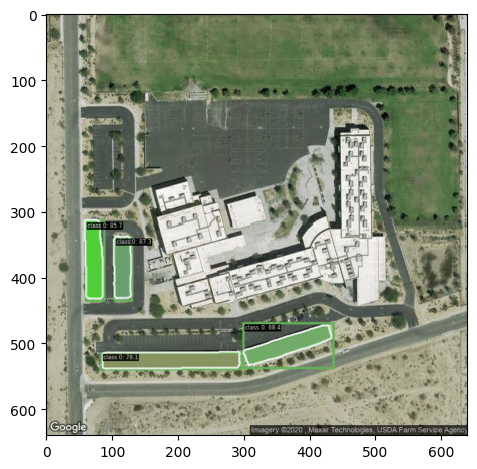

In [16]:
img = mmcv.imread(file_name, channel_order='rgb')
result = inference_detector(model, img)
visualizer.add_datasample(
          file_name,
          img,
          data_sample=result,
          draw_gt=None,
          wait_time=0,
          pred_score_thr=0.35
          )
img = visualizer.get_image()
plt.imshow(img)
plt.tight_layout()
plt.show()

Get the associated labels for each mask and calculate the individual azimuth for each installation.

Label category: carport-fixed-tilt
Label category: carport-fixed-tilt
Label category: carport-fixed-tilt
Label category: carport-fixed-tilt


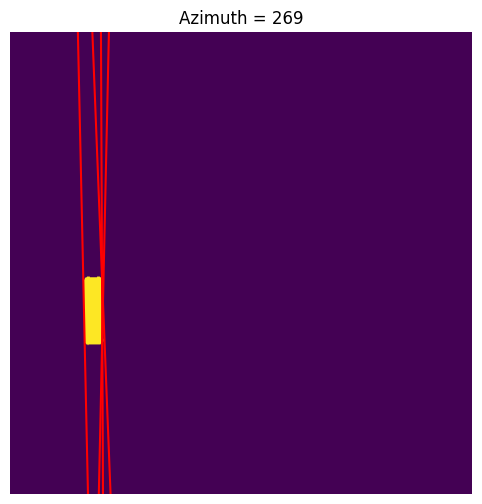

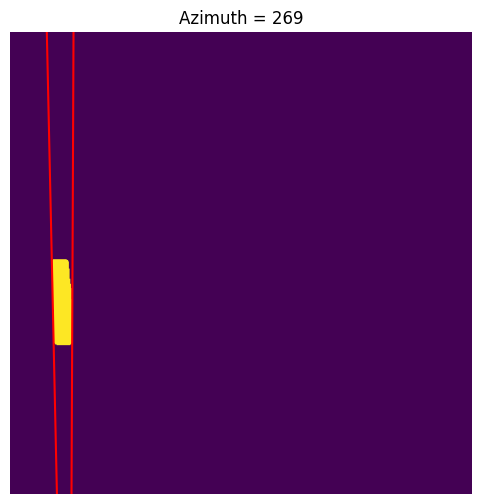

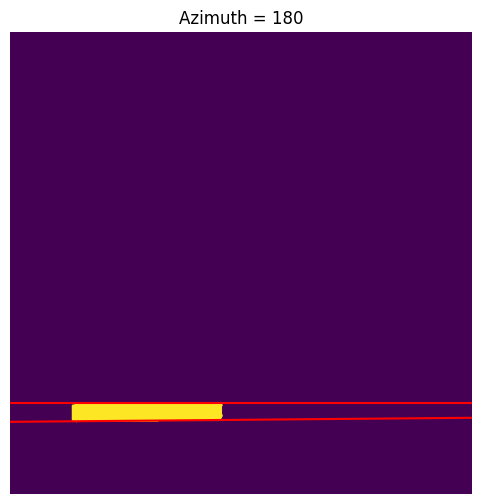

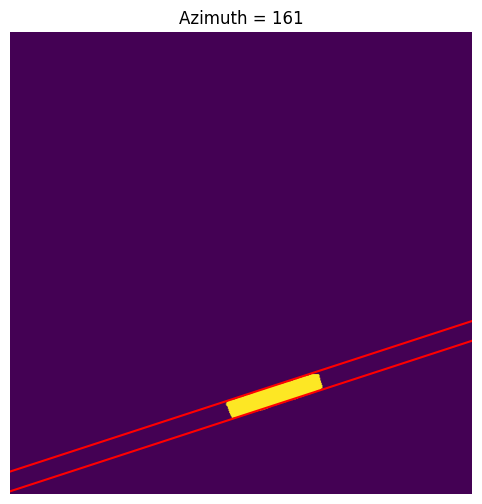

In [17]:
label_categories ={0: "carport-fixed-tilt",
                   1: "ground-dual-axis-tracker", 
                   2: "ground-fixed-tilt",
                   3: "ground-single-axis-tracker", 
                   4: "rooftop-fixed-tilt"}

predictions = result._pred_instances
masks  = predictions.masks
labels = predictions.labels
scores = predictions.scores
idx_to_keep = np.argwhere(scores >= 0.35).tolist()[0]
image_x_pixels, image_y_pixels = result.img_shape
n_kept = 0

for index in range(len(masks)):
    if index in idx_to_keep:
        print(f"Label category: {label_categories[int(labels[index])]}")
        segmentation_mask = masks[index].data.cpu().numpy()
        # Apply the azimuth estimator to the mask
        azimuth = utils.detectAzimuth(segmentation_mask)
        utils.plotEdgeAz(segmentation_mask)